# Explainable AI for the selected Extended CNNs

Notebook 03 ranks all exported Extended-CNN candidates on the fixed `validate` fold and writes an ordered top-three manifest **before loading test**. This notebook consumes that frozen manifest without changing its ranking. The three ranked candidates define the main temporal attribution and faithfulness analyses. The exported FFT candidate is additionally loaded for the dedicated spectral diagnostic, irrespective of its rank; this diagnostic inclusion is not a model-selection decision. Explanations use `validate` trajectories only, while test remains a final performance estimate rather than an explanation-development set.

Three complementary views are used: Layer Grad-CAM localizes influential convolutional activations, Integrated Gradients attributes the prediction back to input time points, and Temporal Occlusion measures the target-logit change after masking windows. Agreement is useful, but visual agreement alone is not treated as biological proof.

## Contents

| Section | Question |
|---|---|
| [1. Frozen selection and data](#setup) | Which models and samples are explained? |
| [2. Attribution protocol](#protocol) | What do the three methods measure? |
| [3. Per-dose attribution maps](#maps) | Which time regions matter by dose? |
| [4. Representative trajectories](#examples) | How do explanations align with actual curves? |
| [5. Spectral Grad-CAM](#spectral) | Does an FFT branch emphasize particular frequencies? |
| [6. Agreement and deletion tests](#validation) | Are maps stable across methods and functionally relevant? |
| [7. Conclusions](#interpretation) | What do the combined diagnostics support? |

<a id="setup"></a>
## 1. Frozen selection and data

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy.stats import spearmanr

from pytorch_timecourse_classification.artifacts import (
    artifact_root, load_model, load_selection_manifest,
)
from pytorch_timecourse_classification.data import (
    Preprocessor, load_prepared_fold, preprocessors_compatible,
)
from pytorch_timecourse_classification.explainability import (
    explainable_layers, integrated_gradients, layer_gradcam,
    normalize_attributions, temporal_occlusion, temporal_window_deletion,
)

In [12]:
FFT_EXPERIMENT_NAME = "extended_cnn_fft"
manifest = load_selection_manifest("extended_cnns_top3.json")
if manifest["selection_fold"] != "validate" or manifest["selection_metric"] != "macro_f1":
    raise ValueError("Notebook 04 expects a validate/macro-F1 selection from Notebook 03.")
selected = manifest["candidates"]
if len(selected) != 3:
    raise ValueError(f"Expected exactly three selected architectures, got {len(selected)}.")
experiment_names = tuple(candidate["experiment"] for candidate in selected)
print("Frozen tune-only selection:")
display(pd.DataFrame(selected).set_index("rank").round(4))

Frozen tune-only selection:


,experiment,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,mcc,macro_roc_auc_ovr,macro_average_precision,log_loss,brier_score
rank,,,,,,,,,,,,
1,extended_cnn_gated_fusion,0.7049,0.7426,0.7221,0.7426,0.7161,0.7058,0.6512,0.9373,0.7440,0.7326,0.4091
2,extended_cnn_first_difference,0.7077,0.7454,0.7229,0.7454,0.7133,0.7073,0.6567,0.9381,0.7501,0.7431,0.4037
3,extended_cnn_tcn,0.7135,0.7086,0.7075,0.7086,0.7059,0.7160,0.6524,0.9375,0.7512,0.7072,0.3731


In [13]:
MINIMUM_FREE_CUDA_GIB = 2.0
cuda_status = "CUDA is unavailable"
device = torch.device("cpu")
if torch.cuda.is_available():
    free_bytes, total_bytes = torch.cuda.mem_get_info()
    free_gib = free_bytes / 1024**3
    total_gib = total_bytes / 1024**3
    cuda_status = f"CUDA memory before attribution: {free_gib:.2f}/{total_gib:.2f} GiB free"
    if free_gib >= MINIMUM_FREE_CUDA_GIB:
        device = torch.device("cuda")
    else:
        cuda_status += f"; below {MINIMUM_FREE_CUDA_GIB:.1f} GiB, using CPU"

models, checkpoints = {}, {}
canonical_preprocessor = None
for experiment_name in experiment_names:
    model, checkpoint = load_model(artifact_root() / experiment_name / "model.pt", device=device)
    if getattr(model, "model_name", None) != "extended_cnn":
        raise TypeError(f"{experiment_name} is not an Extended CNN artifact.")
    preprocessor = Preprocessor(
        tuple(checkpoint["class_names"]), float(checkpoint["signal_mean"]),
        float(checkpoint["signal_std"]),
    )
    if canonical_preprocessor is None: canonical_preprocessor = preprocessor
    elif not preprocessors_compatible(canonical_preprocessor, preprocessor):
        raise ValueError("Selected models use incompatible preprocessing.")
    models[experiment_name] = model
    checkpoints[experiment_name] = checkpoint

if FFT_EXPERIMENT_NAME in models:
    fft_model = models[FFT_EXPERIMENT_NAME]
    fft_checkpoint = checkpoints[FFT_EXPERIMENT_NAME]
else:
    fft_model, fft_checkpoint = load_model(
        artifact_root() / FFT_EXPERIMENT_NAME / "model.pt", device=device,
    )
    if getattr(fft_model, "model_name", None) != "extended_cnn":
        raise TypeError(f"{FFT_EXPERIMENT_NAME} is not an Extended CNN artifact.")
    fft_preprocessor = Preprocessor(
        tuple(fft_checkpoint["class_names"]), float(fft_checkpoint["signal_mean"]),
        float(fft_checkpoint["signal_std"]),
    )
    if not preprocessors_compatible(canonical_preprocessor, fft_preprocessor):
        raise ValueError("The FFT model uses incompatible preprocessing.")

tune_fold = load_prepared_fold("validate", canonical_preprocessor)
class_names = canonical_preprocessor.class_names
print(cuda_status)
print(f"device: {device}; tune shape: {tuple(tune_fold.features.shape)}")
print(f"spectral model: {FFT_EXPERIMENT_NAME} (loaded independently of rank)")

CUDA memory before attribution: 5.73/7.65 GiB free
device: cuda; tune shape: (349, 1, 289)
spectral model: extended_cnn_fft (loaded independently of rank)


In [14]:
SAMPLES_PER_DOSE = 12
rng = np.random.default_rng(42)
targets_numpy = tune_fold.targets.numpy()
analysis_indices = np.concatenate([
    rng.choice(np.flatnonzero(targets_numpy == class_index), size=min(SAMPLES_PER_DOSE, np.sum(targets_numpy == class_index)), replace=False)
    for class_index in range(len(class_names))
])
analysis_indices.sort()
analysis_inputs = tune_fold.features[analysis_indices].to(device)
analysis_targets = tune_fold.targets[analysis_indices].to(device)
print("Balanced explanation cohort:", dict(zip(class_names, np.bincount(analysis_targets.cpu().numpy()))))

Balanced explanation cohort: {'0pM': np.int64(12), '1pM': np.int64(12), '2.5pM': np.int64(12), '5pM': np.int64(12), '25pM': np.int64(12), '100pM': np.int64(12)}


<a id="protocol"></a>
## 2. Attribution protocol

All methods explain the logit of the **true dose class**, not whichever class the model happened to predict. This prevents incorrect predictions from silently receiving a different explanation target. Zero is used as the masking and integration baseline because the inputs were globally z-standardized using train statistics; it corresponds to the training mean signal. Baseline sensitivity remains a limitation and should later be checked against mean and smoothed trajectory baselines.

Attributions are computed in batches of 12 samples. Integrated Gradients retains 64 integration steps but evaluates them through bounded internal batches rather than expanding the complete cohort at once. CUDA is selected only when at least 2 GiB are free before model loading; otherwise the complete attribution workflow uses CPU. This fallback prevents an unrelated GPU process from turning a valid attribution configuration into an out-of-memory failure.

- **Integrated Gradients:** signed accumulated input sensitivity from the zero baseline to the observed trajectory.
- **Temporal Occlusion:** target-logit drop after replacing overlapping windows by the baseline.
- **Layer Grad-CAM:** coarse positive class evidence from the final convolution of each temporal branch, interpolated back to input length. FFT-branch CAMs remain in frequency space and are never presented as temporal maps.

In [15]:
TIME_LENGTH = analysis_inputs.shape[-1]
FFT_LENGTH = TIME_LENGTH // 2 + 1
ATTRIBUTION_BATCH_SIZE = 12
attributions, spectral_cams = {}, {}
attribution_models = dict(models)
attribution_models.setdefault(FFT_EXPERIMENT_NAME, fft_model)
for experiment_name, model in attribution_models.items():
    is_ranked_candidate = experiment_name in models
    layers = explainable_layers(model)
    ig_batches, occlusion_batches = [], []
    temporal_batches = {
        layer.name: [] for layer in layers if layer.domain == "time"
    }
    frequency_batches = {
        layer.name: [] for layer in layers if layer.domain == "frequency"
    }
    for start in range(0, len(analysis_inputs), ATTRIBUTION_BATCH_SIZE):
        batch_inputs = analysis_inputs[start:start + ATTRIBUTION_BATCH_SIZE]
        batch_targets = analysis_targets[start:start + ATTRIBUTION_BATCH_SIZE]
        if is_ranked_candidate:
            ig_batches.append(integrated_gradients(
                model, batch_inputs, batch_targets, steps=64,
                internal_batch_size=len(batch_inputs),
            ))
            occlusion_batches.append(temporal_occlusion(
                model, batch_inputs, batch_targets, window_size=17, stride=4,
            ))
        for layer in layers:
            if not is_ranked_candidate and layer.domain != "frequency":
                continue
            output_length = TIME_LENGTH if layer.domain == "time" else FFT_LENGTH
            cam = normalize_attributions(layer_gradcam(
                model, batch_inputs, batch_targets, layer,
                output_length=output_length,
            ))
            target = temporal_batches if layer.domain == "time" else frequency_batches
            target[layer.name].append(cam)
    frequency_maps = {
        name: torch.cat(batches)
        for name, batches in frequency_batches.items()
    }
    spectral_cams[experiment_name] = frequency_maps
    if is_ranked_candidate:
        temporal_maps = [
            torch.cat(temporal_batches[layer.name])
            for layer in layers if layer.domain == "time"
        ]
        gradcam = torch.stack(temporal_maps).mean(dim=0)
        attributions[experiment_name] = {
            "Integrated Gradients": normalize_attributions(torch.cat(ig_batches)),
            "Temporal Occlusion": normalize_attributions(torch.cat(occlusion_batches)),
            "Layer Grad-CAM": normalize_attributions(gradcam),
        }
    print(experiment_name, getattr(model, "architecture", None), [layer.name for layer in layers])

extended_cnn_gated_fusion gated_fusion ['raw', 'first_difference']
extended_cnn_first_difference first_difference ['raw', 'first_difference']
extended_cnn_tcn tcn ['tcn']
extended_cnn_fft fft ['raw', 'first_difference', 'fft_magnitude']


<a id="maps"></a>
## 3. Per-dose attribution maps

Each row averages independently normalized sample maps for one true dose. This reveals recurring temporal preferences without letting a few high-amplitude attribution maps dominate the mean. It does not show uncertainty, so the later sample-level agreement and deletion analyses remain necessary.

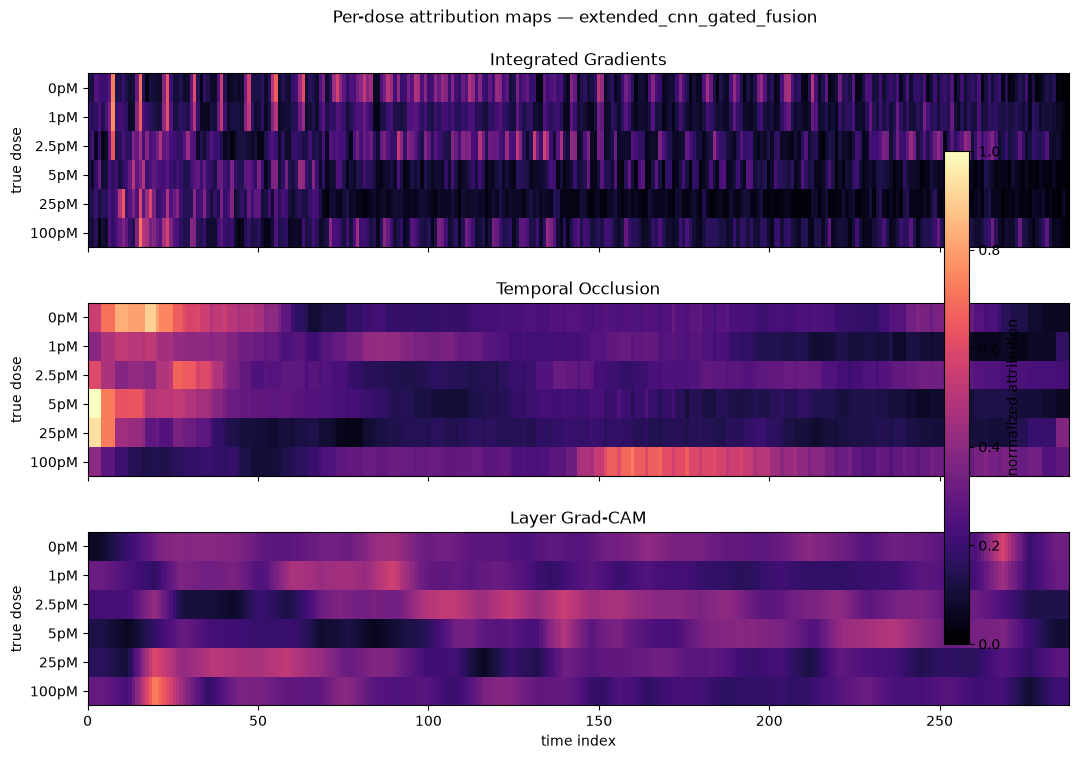

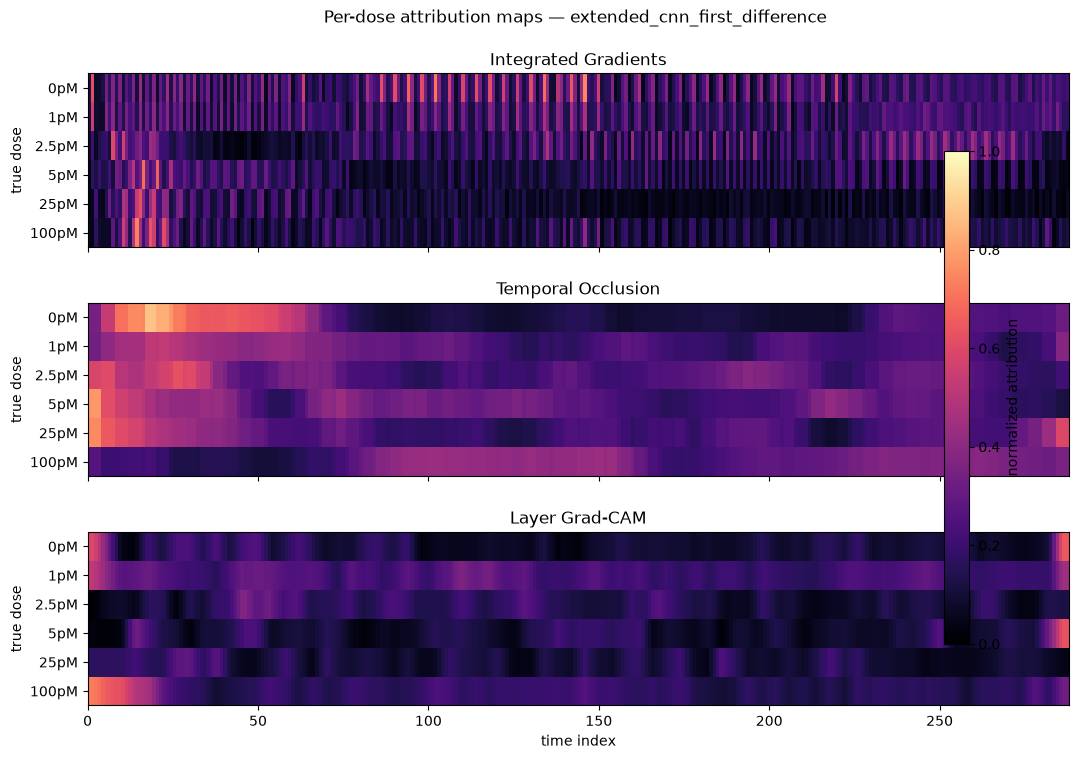

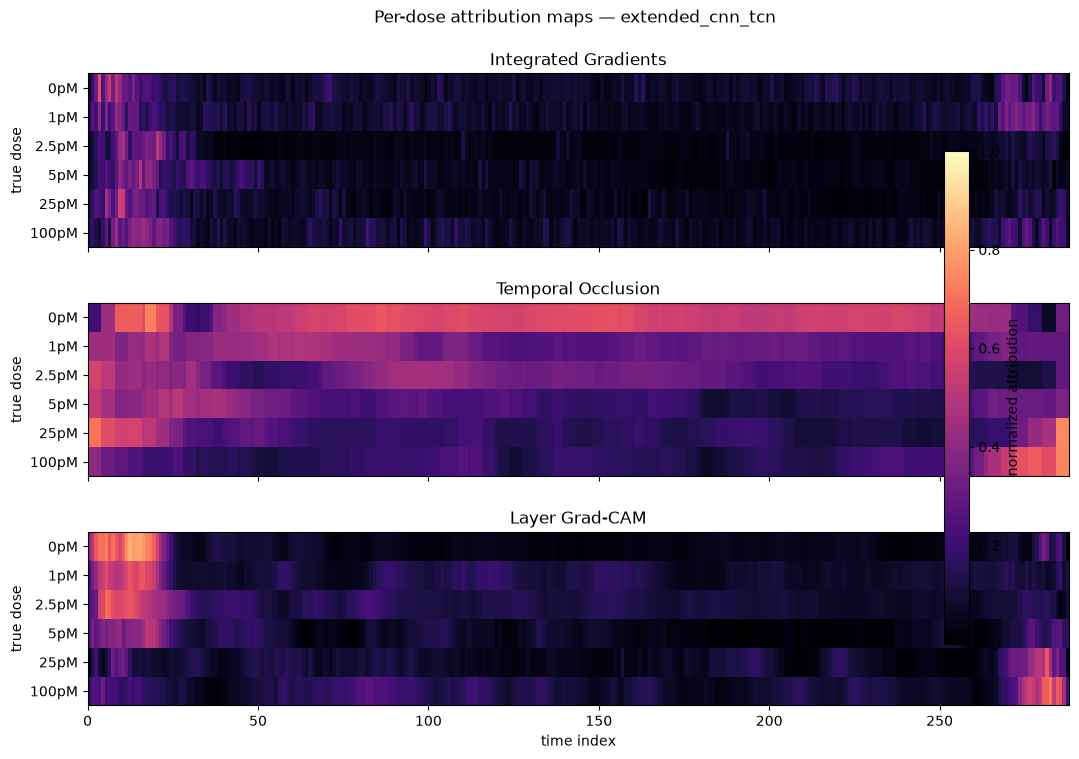

In [6]:
time_axis = np.arange(TIME_LENGTH)
for experiment_name, methods in attributions.items():
    figure, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True, sharey=True)
    for axis, (method_name, values) in zip(axes, methods.items()):
        dose_maps = torch.stack([
            values[analysis_targets == class_index].mean(dim=0).squeeze(0)
            for class_index in range(len(class_names))
]).cpu().numpy()
        image = axis.imshow(dose_maps, aspect="auto", cmap="magma", vmin=0, vmax=1, extent=(0, TIME_LENGTH - 1, len(class_names) - 0.5, -0.5))
        axis.set(title=method_name, yticks=np.arange(len(class_names)), yticklabels=class_names, ylabel="true dose")
    axes[-1].set_xlabel("time index")
    figure.colorbar(image, ax=axes, label="normalized attribution", shrink=0.8)
    figure.suptitle(f"Per-dose attribution maps — {experiment_name}")
    figure.subplots_adjust(top=0.90, right=0.88, hspace=0.32)

### Interpretation

The three ranked models consistently use information from the early response, but they distribute relevance differently over the remaining trajectory. The TCN is the most localized: its dose averages emphasize approximately the first 20–30 time points and, for the highest dose, the end of the sequence. Gated fusion and first difference produce broader, more dose-dependent regions, especially in the occlusion maps. Integrated Gradients is visibly more fragmented than occlusion or Grad-CAM, which is expected for pointwise sensitivity on temporally correlated signals. The differences between methods already indicate that no single narrow interval is supported as the unique explanation across architectures.

<a id="examples"></a>
## 4. Representative trajectories

One deterministic trajectory per true dose is shown for each model. Point color represents normalized relevance. These plots are examples rather than evidence of population-level behavior; interpret them together with the dose-average maps.

In [7]:
def plot_colored_trajectory(axis, trajectory, attribution, title):
    axis.plot(time_axis, trajectory, color="0.45", linewidth=1.0, zorder=1)
    points = axis.scatter(time_axis, trajectory, c=attribution, cmap="magma", vmin=0, vmax=1, s=10, zorder=2)
    axis.set_title(title, fontsize=9)
    axis.grid(alpha=0.15)
    return points
representative_positions = [
    int(torch.nonzero(analysis_targets == class_index, as_tuple=False)[0])
    for class_index in range(len(class_names))
]

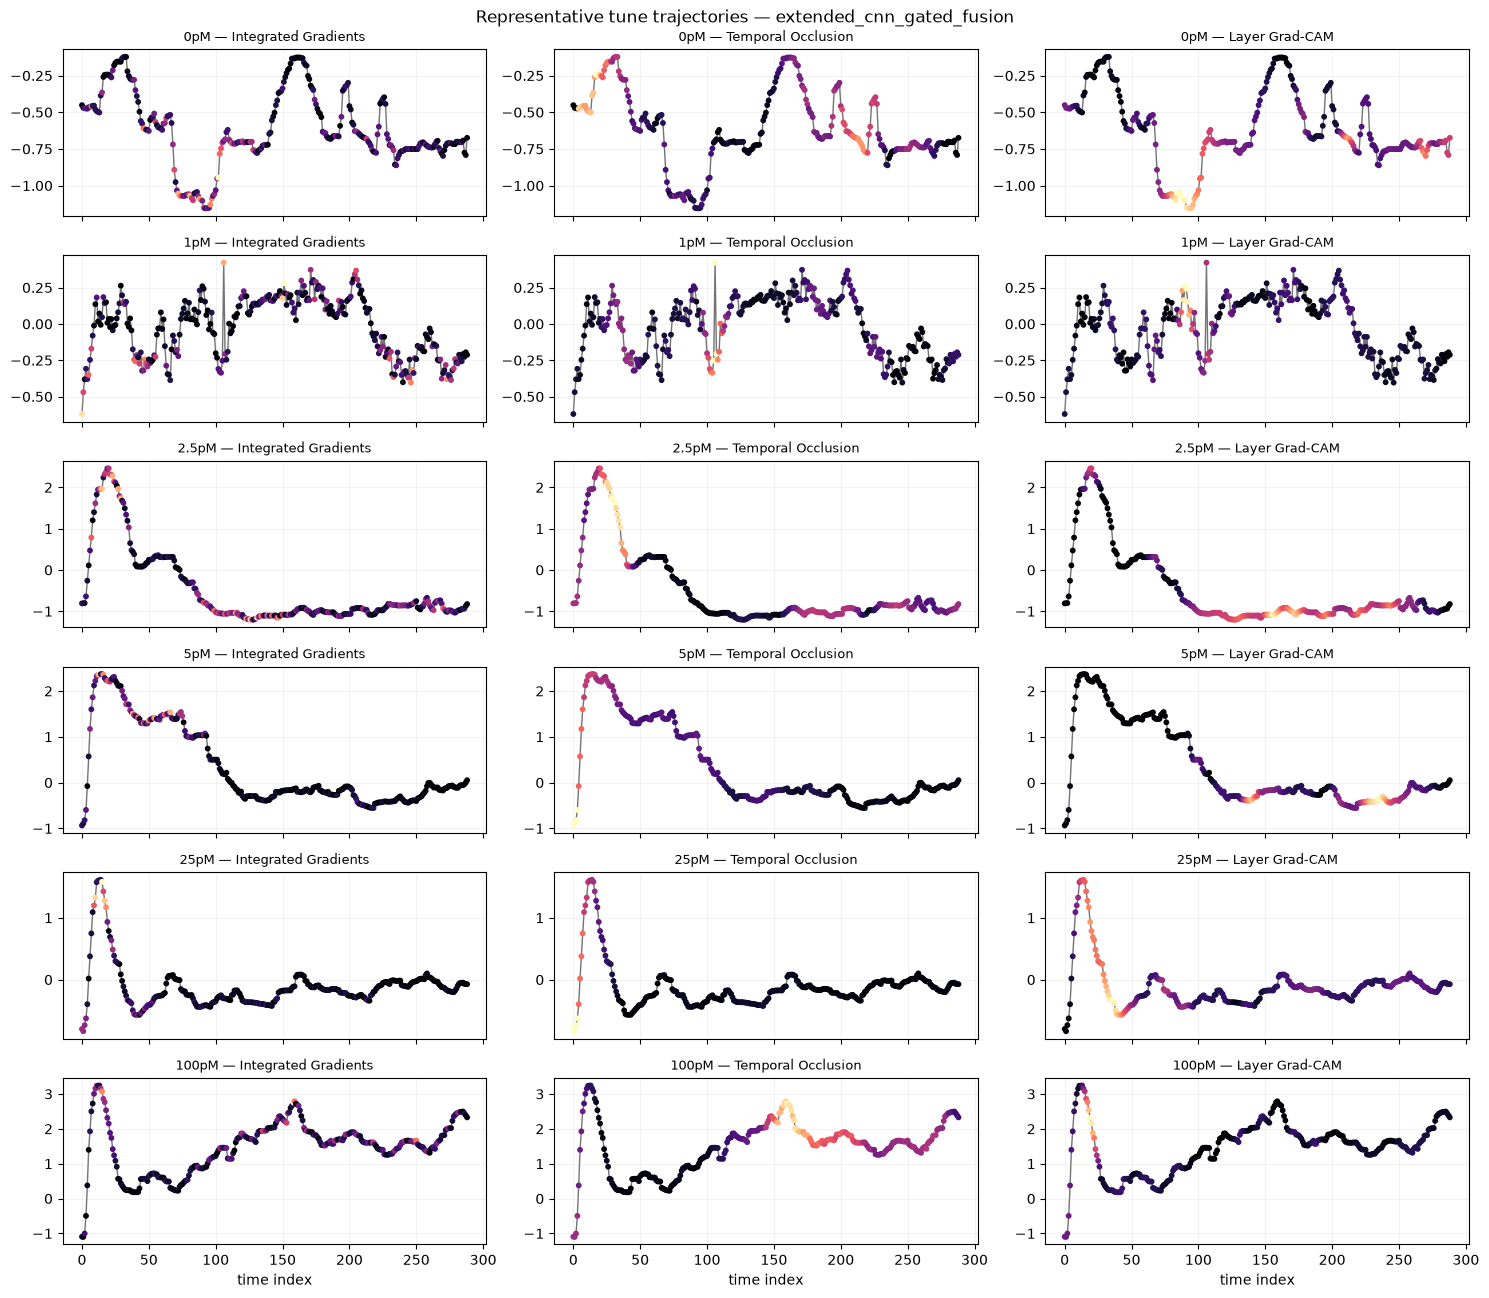

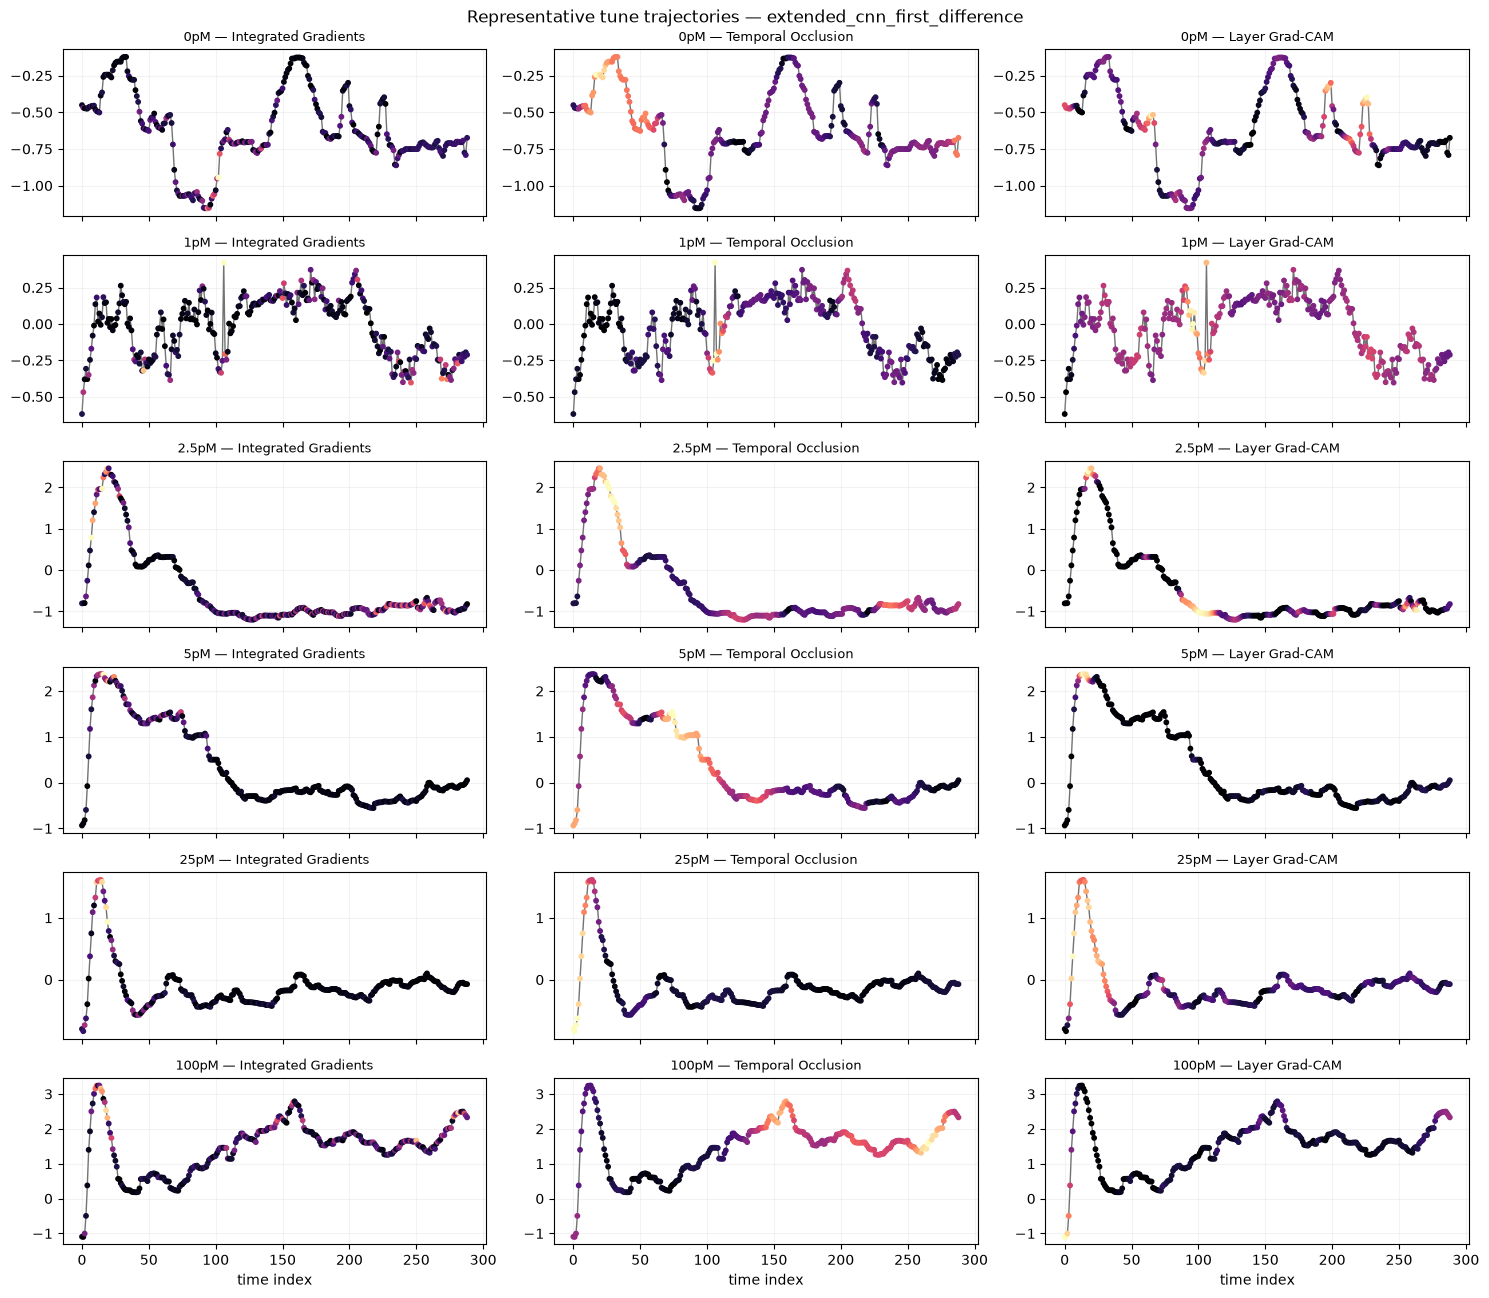

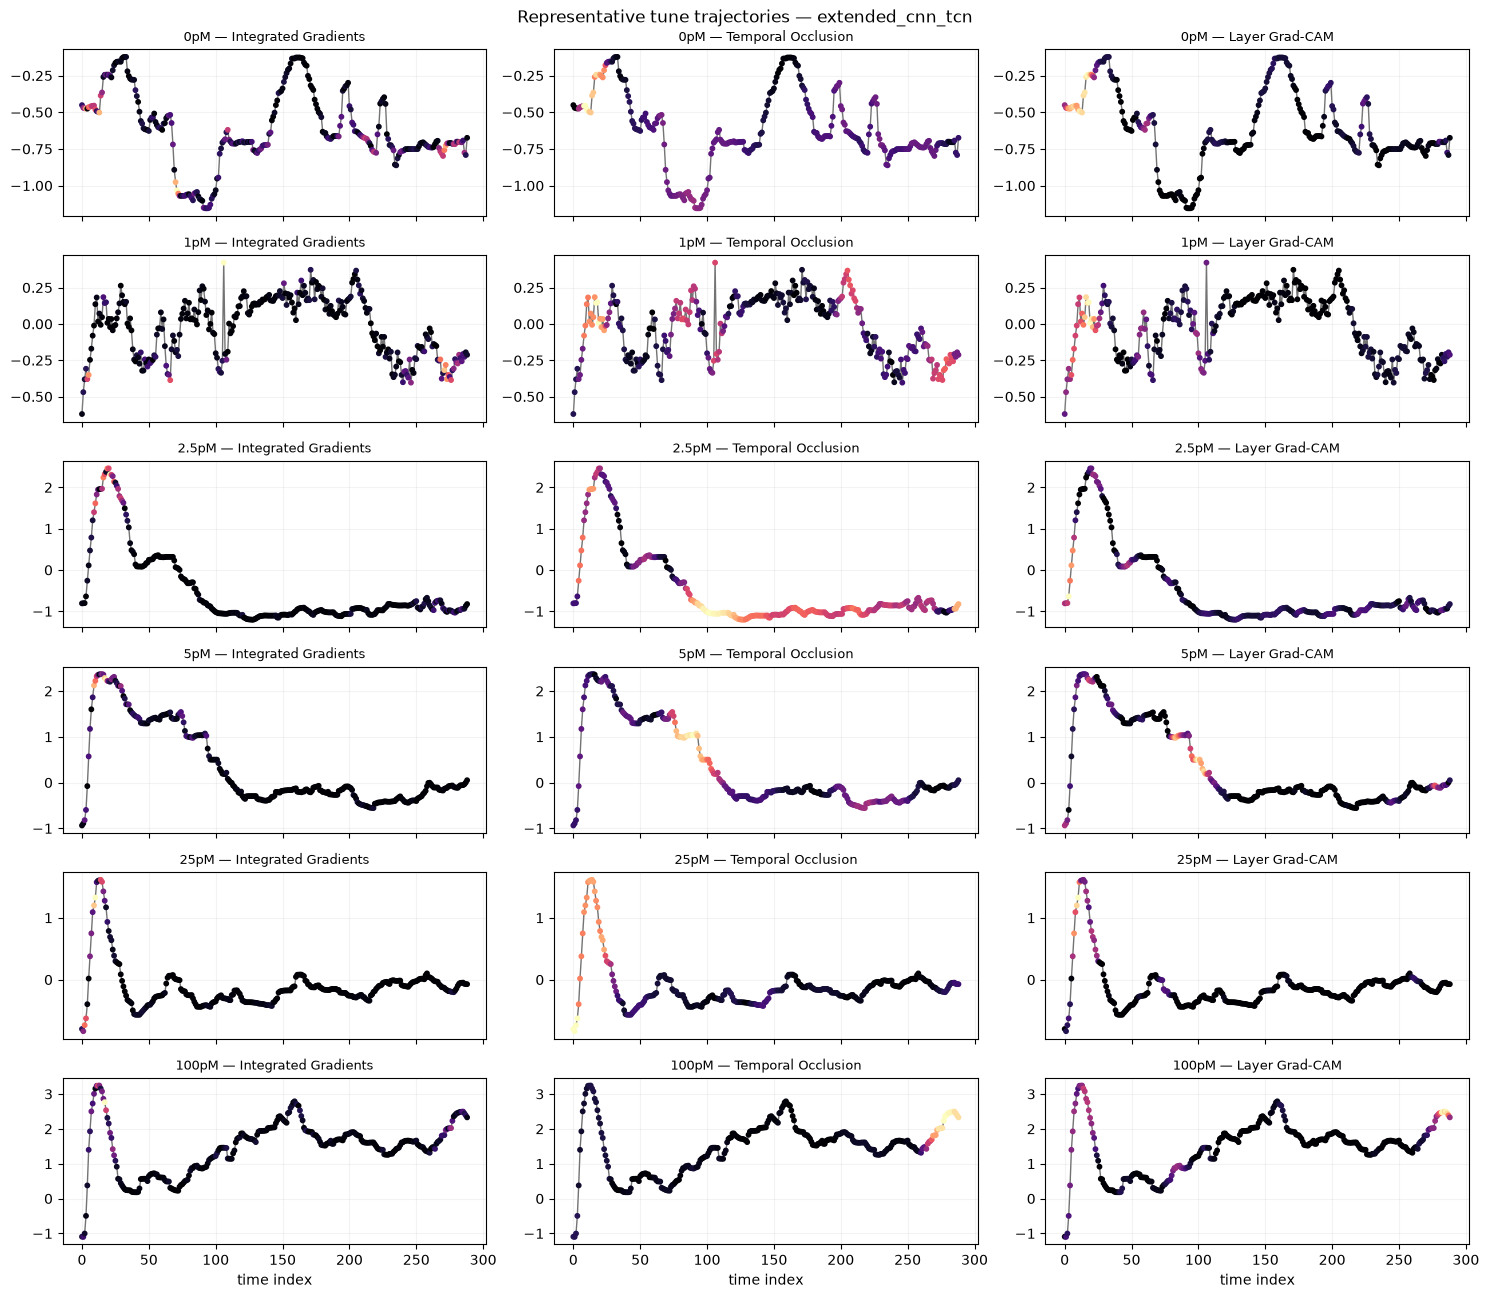

In [8]:
for experiment_name, methods in attributions.items():
    figure, axes = plt.subplots(len(class_names), len(methods), figsize=(15, 2.2 * len(class_names)), sharex=True)
    for row, position in enumerate(representative_positions):
        trajectory = analysis_inputs[position, 0].detach().cpu().numpy()
        for column, (method_name, values) in enumerate(methods.items()):
            plot_colored_trajectory(
                axes[row, column], trajectory, values[position, 0].cpu().numpy(),
                f"{class_names[row]} — {method_name}",
            )
    for axis in axes[-1]: axis.set_xlabel("time index")
    figure.suptitle(f"Representative tune trajectories — {experiment_name}")
    figure.tight_layout()

### Interpretation

The representative trajectories connect the averaged maps to recognizable response phases. For 2.5–25 pM, relevance frequently overlaps the initial rise, peak, and early decay; the 100 pM example additionally contains relevant later dynamics. The irregular 1 pM trajectory receives more dispersed relevance, consistent with a less compact temporal signature. Agreement is qualitative rather than exact: TCN explanations are comparatively concentrated, whereas gated fusion and first difference often distribute relevance across several events. Because each row contains only one deterministic example, these plots illustrate the attribution patterns but do not establish their population-level stability.

<a id="spectral"></a>
## 5. Spectral Grad-CAM

The exported FFT model is loaded specifically for this diagnostic, irrespective of whether it belongs to the frozen top-three ranking. Its inclusion therefore supplies the required frequency-domain view without changing the selected candidates used in the other analyses. The horizontal axis is normalized frequency. Magnitude-only FFT features discard phase, so their Grad-CAM cannot identify when an event occurred. Input-level Integrated Gradients and Temporal Occlusion provide temporal views for ranked FFT candidates because they differentiate or perturb the original trajectory through the complete model.

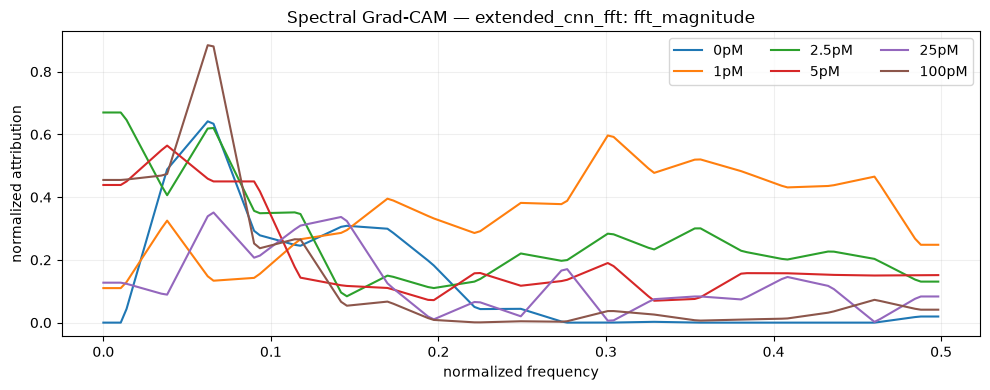

In [16]:
frequency_axis = np.fft.rfftfreq(TIME_LENGTH)
fft_maps = spectral_cams.get(FFT_EXPERIMENT_NAME, {})
if not fft_maps:
    raise RuntimeError(f"No frequency-domain Grad-CAM was produced for {FFT_EXPERIMENT_NAME}.")
for layer_name, values in fft_maps.items():
    figure, axis = plt.subplots(figsize=(10, 4))
    for class_index, class_name in enumerate(class_names):
        mean_map = values[analysis_targets == class_index].mean(dim=0).squeeze().cpu().numpy()
        axis.plot(frequency_axis, mean_map, label=class_name)
    axis.set(title=f"Spectral Grad-CAM — {FFT_EXPERIMENT_NAME}: {layer_name}", xlabel="normalized frequency", ylabel="normalized attribution")
    axis.legend(ncol=3); axis.grid(alpha=0.2); figure.tight_layout()

### Interpretation

The FFT branch shows class-dependent frequency preferences. The 0, 2.5, 5, and 100 pM curves place their strongest emphasis primarily in the low-frequency range around 0.03–0.08, while 1 pM retains broad relevance across roughly 0.20–0.46 with a maximum near 0.30. The 25 pM curve is weaker and distributed across low and intermediate frequencies. Since every sample map is normalized before aggregation, curve heights cannot be interpreted as differences in total evidence between doses. The result supports the use of distinct frequency bands by the FFT model, but it provides no temporal localization and does not affect the frozen top-three ranking.

<a id="validation"></a>
## 6. Agreement and deletion tests

Spearman correlation compares the ranking of time points, not their absolute scale. The deletion test then masks the most important 17-point window and compares its true-class logit drop with a seed-matched random window. A useful explanation should usually produce a larger top-window drop than the random control. This is a faithfulness diagnostic, not proof that the same interval is biologically causal.

In [10]:
agreement_rows, deletion_rows = [], []
for experiment_name, methods in attributions.items():
    method_items = list(methods.items())
    for left_index, (left_name, left_values) in enumerate(method_items):
        for right_name, right_values in method_items[left_index + 1:]:
            correlations = [
                spearmanr(left_values[index].cpu().flatten(), right_values[index].cpu().flatten()).statistic
                for index in range(len(analysis_inputs))
]
            agreement_rows.append({
                "experiment": experiment_name, "comparison": f"{left_name} vs {right_name}",
                "mean_spearman": np.nanmean(correlations), "std_spearman": np.nanstd(correlations),
            })
    for method_name in ("Integrated Gradients", "Layer Grad-CAM"):
        deletion = temporal_window_deletion(
            models[experiment_name], analysis_inputs, analysis_targets, methods[method_name],
            window_size=17, random_seed=42,
        )
        for strategy in ("top", "random"):
            values = deletion[strategy].cpu().numpy()
            deletion_rows.append({
                "experiment": experiment_name, "method": method_name, "window": strategy,
                "mean_logit_drop": values.mean(), "std_logit_drop": values.std(),
            })
agreement = pd.DataFrame(agreement_rows)
deletion_summary = pd.DataFrame(deletion_rows)
display(agreement.round(3))
display(deletion_summary.round(3))

,experiment,comparison,mean_spearman,std_spearman
0,extended_cnn_gated_fusion,Integrated Gradients vs Temporal Occlusion,0.163,0.206
1,extended_cnn_gated_fusion,Integrated Gradients vs Layer Grad-CAM,0.084,0.226
2,extended_cnn_gated_fusion,Temporal Occlusion vs Layer Grad-CAM,-0.004,0.293
3,extended_cnn_first_difference,Integrated Gradients vs Temporal Occlusion,0.169,0.199
4,extended_cnn_first_difference,Integrated Gradients vs Layer Grad-CAM,0.050,0.196
5,extended_cnn_first_difference,Temporal Occlusion vs Layer Grad-CAM,0.058,0.252
6,extended_cnn_tcn,Integrated Gradients vs Temporal Occlusion,0.203,0.231
7,extended_cnn_tcn,Integrated Gradients vs Layer Grad-CAM,0.129,0.147
8,extended_cnn_tcn,Temporal Occlusion vs Layer Grad-CAM,0.094,0.272


,experiment,method,window,mean_logit_drop,std_logit_drop
0,extended_cnn_gated_fusion,Integrated Gradients,top,0.501,1.438
1,extended_cnn_gated_fusion,Integrated Gradients,random,0.307,0.993
2,extended_cnn_gated_fusion,Layer Grad-CAM,top,0.023,1.085
3,extended_cnn_gated_fusion,Layer Grad-CAM,random,0.307,0.993
4,extended_cnn_first_difference,Integrated Gradients,top,0.633,1.181
5,extended_cnn_first_difference,Integrated Gradients,random,0.242,0.798
6,extended_cnn_first_difference,Layer Grad-CAM,top,0.510,0.796
7,extended_cnn_first_difference,Layer Grad-CAM,random,0.242,0.798
8,extended_cnn_tcn,Integrated Gradients,top,0.714,1.177
9,extended_cnn_tcn,Integrated Gradients,random,-0.063,0.764


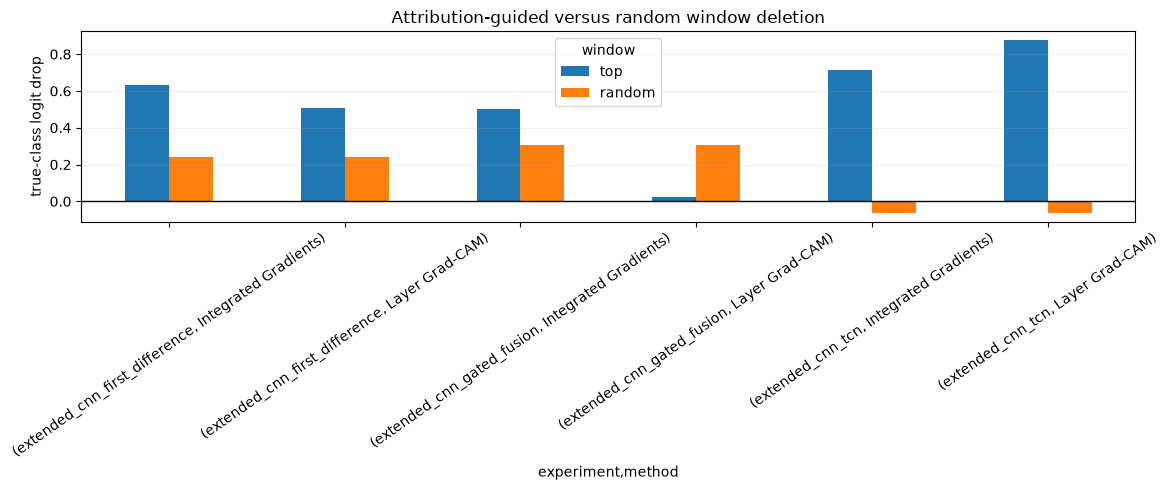

In [11]:
deletion_plot = deletion_summary.pivot(index=["experiment", "method"], columns="window", values="mean_logit_drop")
deletion_plot[["top", "random"]].plot.bar(figsize=(12, 5), rot=35)
plt.axhline(0, color="black", linewidth=1)
plt.ylabel("true-class logit drop"); plt.title("Attribution-guided versus random window deletion")
plt.grid(axis="y", alpha=0.2); plt.tight_layout()

### Interpretation

Method agreement is weak at sample level: mean Spearman correlations range from approximately 0.05 to 0.20, with gated-fusion occlusion versus Grad-CAM effectively uncorrelated (-0.004). The deletion test nevertheless provides functional support for several maps. TCN has the clearest separation from its random control: mean logit drops are 0.714 for Integrated Gradients and 0.877 for Grad-CAM, compared with -0.063 for random windows. First difference also shows consistent separation (0.633 and 0.510 versus 0.242). Gated-fusion Integrated Gradients provides only modest separation (0.501 versus 0.307), while its Grad-CAM does not pass this diagnostic (0.023 versus 0.307). The large sample-level standard deviations of roughly 0.8–1.4 make these average effects heterogeneous rather than universal.

<a id="interpretation"></a>
## 7. Conclusions

The combined diagnostics show that the selected Extended CNNs use genuine temporal structure, but they do not support one architecture-independent importance map. Early response phases recur across dose averages and representative trajectories, while later relevance depends more strongly on dose and architecture. TCN provides the strongest functional attribution evidence in the deletion test, followed by first difference. Gated fusion is less consistent, and its Grad-CAM result is not supported by the deletion control.

The FFT analysis adds a complementary result: the dedicated FFT model separates doses partly through different frequency regions, with prominent low-frequency relevance for several doses and broader intermediate-to-high-frequency relevance for 1 pM. This frequency-domain evidence is descriptive, cannot locate an event in time, and does not elevate the FFT model into the frozen top-three selection.

The low cross-method correlations and large deletion-score variation limit stronger claims. Normalization removes absolute attribution magnitude, the zero baseline is only one plausible reference, and neighboring time points are highly correlated. Moreover, selection and explanation both use `validate`, so these results characterize the frozen candidates but are not an independent generalization estimate. Overall, the evidence is strongest for a distributed, dose- and architecture-dependent use of early response dynamics rather than for a single universally decisive time window.